# Notebook 01m - PPO baseline on `MiniGrid-BlockedUnlockPickup-v0`

Train the PPO baseline for BlockedUnlockPickup using `config/envs/blockedunlockpickup.yaml`.
RL Baselines3 Zoo does not list a tuned row for this task, so this starts from
the repo's successful fixed-layout/action-floor UnlockPickup recipe while
keeping fully observable MiniGrid image observations for the later PPO-CF oracle.


---
## Knobs


In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "blockedunlockpickup"
SEEDS         = None          # None -> use the config's seeds
FORCE_RETRAIN = True

# OVERRIDES = {
#     # Quick-smoke overrides:
#     # "ppo.total_timesteps": 100_000,
#     "run.seeds": (0,),
# }
OVERRIDES = {
    "run.run_name": "blockedunlockpickup_cleanrl_style",
    "run.seeds": (0,),

    "env.layout_seeds": (0,),
    "env.n_envs": 16,

    "ppo.total_timesteps": 10_000_000,
    "ppo.n_steps": 128,
    "ppo.n_epochs": 4,
    "ppo.n_minibatches": 8,    # minibatch 256
    "ppo.learning_rate": 0.00025,
    "ppo.anneal_lr": True,

    "ppo.ent_coef": 0.01,
    "ppo.prob_floor_start": 0.0,
    "ppo.prob_floor_end": 0.0,

    "reward.potential_shaping": False,
    "reward.count_bonus_coef": 0.0,
}

# ----------------------------------------------------------------------------


## 0. Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, validate, load_checkpoint, list_checkpoints
from envs.env_pool import make_env
from utils.logging import read_scalars
from utils.plotting import plot_learning_curves, plot_episode_returns, plot_grid, savefig
from scripts.train import run_seeds

cfg = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    cfg = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(cfg.run.seeds)
RUN_NAME = cfg.run.run_name
FIG = FIGURES_DIR / f"nb01_blockedunlockpickup_{RUN_NAME}"
FIG.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = ["left", "right", "forward", "pickup", "drop", "toggle", "done"]
SUBGOAL_NAMES = ("key picked", "locked door open")
print(cfg.summary())
print()
print(f"run: {RUN_NAME}   seeds: {list(SEEDS)}")


config             blockedunlockpickup
env                MiniGrid-BlockedUnlockPickup-v0  (n_envs=16, obs_norm=image)
layouts            1 fixed (cycle)
total_timesteps    10,000,000  per seed
rollout batch      2048  (16 envs x 128 steps)
updates            4,882
minibatch size     256  x 4 epochs
gamma / lambda     0.99 / 0.95
lr                 0.00025  (anneal=True)
encoder            cnn  (shared=True)
entropy            fixed, coef 0.01
prob floor         0.0 -> 0.0  (0 = off)
adv norm           batch  (min_std 1e-06)
policy gradient    gae


reward shaping     off
warm start         none
seeds              [0]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

run: blockedunlockpickup_cleanrl_style   seeds: [0]


## 1. Train


In [3]:
already = all((seed_dir(RUN_NAME, s) / "scalars.csv").exists() for s in SEEDS)

if already and not FORCE_RETRAIN:
    print(f"found existing run at {RUNS_DIR / RUN_NAME} -- skipping training")
else:
    t0 = time.time()
    outputs = run_seeds(cfg)
    print()
    print(f"training finished in {(time.time() - t0) / 60:.1f} min")



=== seed 0 ====================================================


/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


  upd    10/4882  step   20,480  ret   0.000  succ 0.00  sg1 0.75 sg2 0.00  ent 1.916  advstd 8.03e-03  ev -1.325  1,540 sps
  upd    20/4882  step   40,960  ret   0.000  succ 0.00  sg1 0.78 sg2 0.02  ent 1.854  advstd 7.58e-03  ev -1.421  1,586 sps
  upd    30/4882  step   61,440  ret   0.000  succ 0.00  sg1 0.79 sg2 0.01  ent 1.885  advstd 6.84e-03  ev -0.360  1,604 sps
  upd    40/4882  step   81,920  ret   0.000  succ 0.00  sg1 0.83 sg2 0.02  ent 1.832  advstd 1.07e-02  ev -0.117  1,613 sps
  upd    50/4882  step  102,400  ret   0.000  succ 0.00  sg1 0.82 sg2 0.03  ent 1.908  advstd 5.58e-03  ev -0.519  1,616 sps
  upd    60/4882  step  122,880  ret   0.000  succ 0.00  sg1 0.84 sg2 0.04  ent 1.830  advstd 4.86e-03  ev -1.679  1,617 sps
  upd    70/4882  step  143,360  ret   0.000  succ 0.00  sg1 0.80 sg2 0.03  ent 1.886  advstd 3.91e-03  ev  0.371  1,619 sps
  upd    80/4882  step  163,840  ret   0.000  succ 0.00  sg1 0.77 sg2 0.02  ent 1.840  advstd 5.06e-03  ev  0.109  1,621 sps


## 2. Load Outputs


In [4]:
scalars = {}
episodes = {}
for s in SEEDS:
    sd = seed_dir(RUN_NAME, s)
    if (sd / "scalars.csv").exists():
        scalars[s] = read_scalars(sd / "scalars.csv")
    if (sd / "episodes.csv").exists():
        episodes[s] = pd.read_csv(sd / "episodes.csv")

summary = []
for s, d in scalars.items():
    row = {
        "seed": s,
        "steps": int(d["global_step"].iloc[-1]),
        "final_return_100": round(float(d["mean_return_100"].iloc[-1]), 3),
        "final_success_100": round(float(d["success_rate_100"].iloc[-1]), 3),
        "best_success_100": round(float(d["success_rate_100"].max()), 3),
        "final_sg1": round(float(d["subgoal1_rate_100"].iloc[-1]), 3) if "subgoal1_rate_100" in d else None,
        "final_sg2": round(float(d["subgoal2_rate_100"].iloc[-1]), 3) if "subgoal2_rate_100" in d else None,
        "median_entropy": round(float(d["entropy"].median()), 3),
        "median_ev": round(float(d["explained_variance"].median()), 3),
    }
    summary.append(row)
display(pd.DataFrame(summary))


,seed,steps,final_return_100,final_success_100,best_success_100,final_sg1,final_sg2,median_entropy,median_ev
0,0,9998336,0.331,0.63,0.66,0.98,0.72,1.707,0.237


## 3. Return And Subgoals


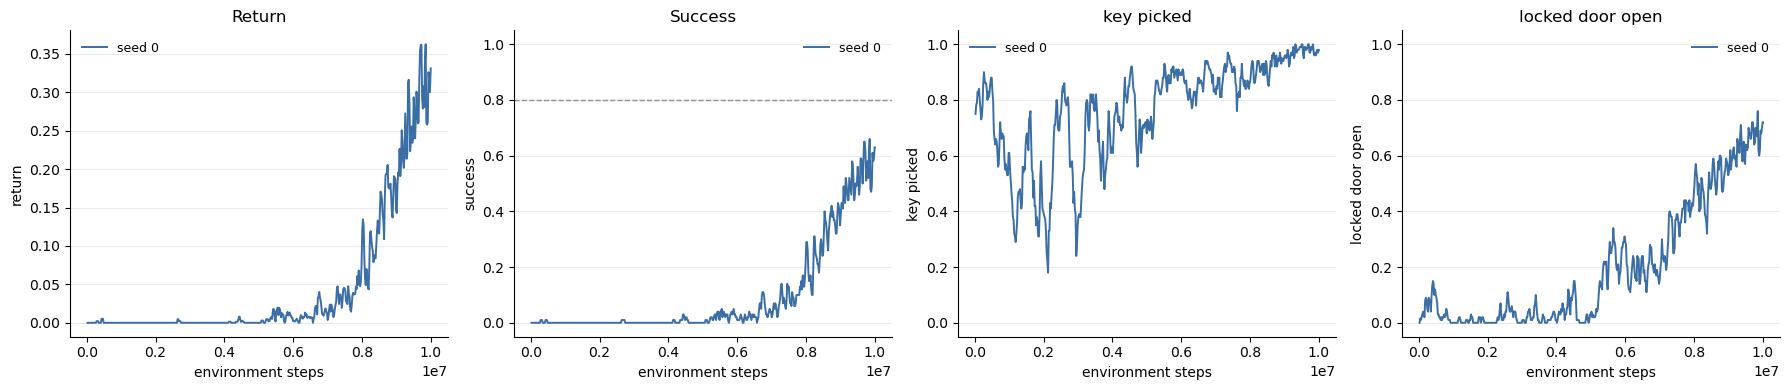

In [5]:
if scalars:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    plot_learning_curves(scalars, y="mean_return_100", ylabel="return", title="Return", ax=axes[0])
    plot_learning_curves(scalars, y="success_rate_100", ylabel="success", title="Success", hline=0.8, ax=axes[1])
    if "subgoal1_rate_100" in next(iter(scalars.values())).columns:
        plot_learning_curves(scalars, y="subgoal1_rate_100", ylabel=SUBGOAL_NAMES[0], title=SUBGOAL_NAMES[0], ax=axes[2])
        plot_learning_curves(scalars, y="subgoal2_rate_100", ylabel=SUBGOAL_NAMES[1], title=SUBGOAL_NAMES[1], ax=axes[3])
    for ax in axes[1:]:
        ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    savefig(fig, FIG / "learning.png")
    plt.show()


## 4. Optimisation Diagnostics


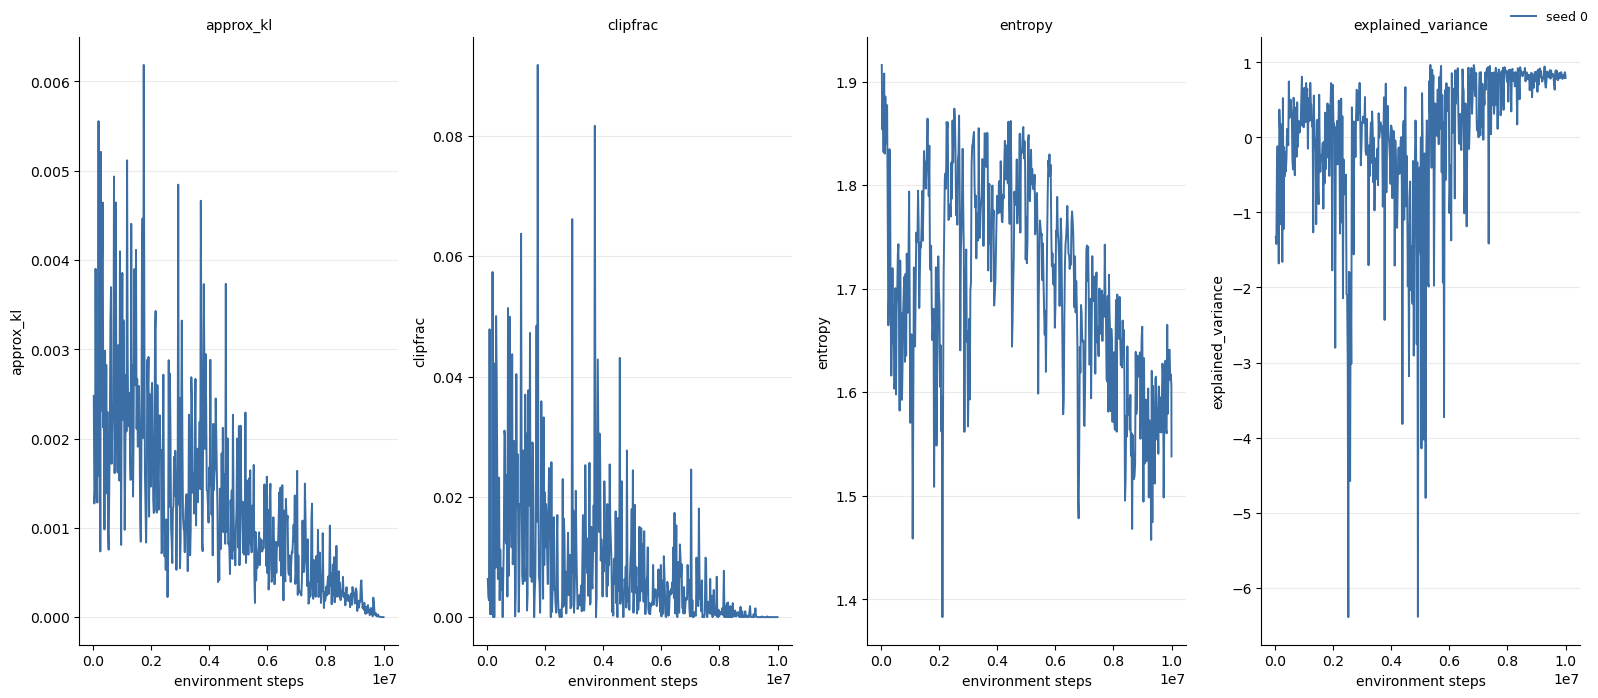

In [6]:
if scalars:
    keys = [k for k in ["loss", "policy_loss", "value_loss", "approx_kl", "clipfrac", "adv_std", "entropy", "explained_variance"]
            if k in next(iter(scalars.values())).columns]
    fig = plot_grid(scalars, keys, ncols=4, figsize=(16, 7))
    savefig(fig, FIG / "optimisation.png")
    plt.show()


## 5. Action Diagnostics


,seed,action,sample_frac,mean_pi,p05_pi,p95_pi
0,0,left,0.150639,0.150459,0.035197,0.354441
1,0,right,0.085531,0.085933,0.003484,0.244554
2,0,forward,0.201690,0.201584,0.019499,0.528402
3,0,pickup,0.165053,0.164953,0.057709,0.355214
4,0,drop,0.113449,0.113513,0.032513,0.253396
5,0,toggle,0.152025,0.151706,0.037878,0.299148
6,0,done,0.131612,0.131852,0.036854,0.284258


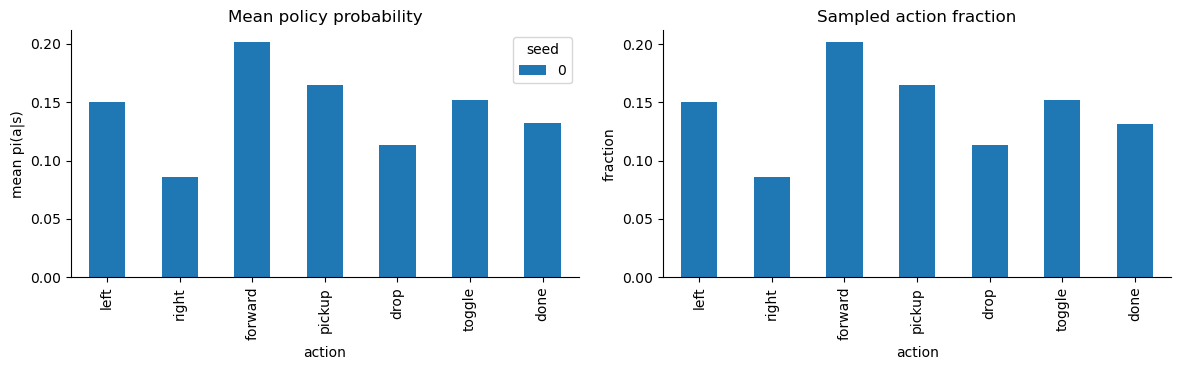

In [7]:
action_rows = []
for s in SEEDS:
    path = seed_dir(RUN_NAME, s) / "trajectories.npz"
    if not path.exists():
        continue
    traj = load_trajectories(path)
    acts = traj.action.astype(int)
    probs = traj.probs.astype(float)
    for a, name in enumerate(ACTION_NAMES):
        action_rows.append({
            "seed": s,
            "action": name,
            "sample_frac": float((acts == a).mean()),
            "mean_pi": float(probs[:, a].mean()),
            "p05_pi": float(np.quantile(probs[:, a], 0.05)),
            "p95_pi": float(np.quantile(probs[:, a], 0.95)),
        })
action_df = pd.DataFrame(action_rows)
display(action_df)

if not action_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    piv = action_df.pivot(index="action", columns="seed", values="mean_pi").loc[ACTION_NAMES]
    piv.plot(kind="bar", ax=axes[0], legend=True)
    axes[0].set_title("Mean policy probability")
    axes[0].set_ylabel("mean pi(a|s)")
    axes[0].spines[["top", "right"]].set_visible(False)
    piv2 = action_df.pivot(index="action", columns="seed", values="sample_frac").loc[ACTION_NAMES]
    piv2.plot(kind="bar", ax=axes[1], legend=False)
    axes[1].set_title("Sampled action fraction")
    axes[1].set_ylabel("fraction")
    axes[1].spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    savefig(fig, FIG / "actions.png")
    plt.show()


## 6. Checkpoints And Greedy Evaluation


In [8]:
def greedy_eval(ck, n_episodes=50, seed0=90_000):
    env = make_env(cfg.env.env_id, cfg.env.max_episode_steps, fully_observable=cfg.env.fully_observable)
    returns = []
    successes = []
    lengths = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + ep)
        done = False
        ret = 0.0
        t = 0
        while not done:
            x = np.asarray(obs, dtype=np.float32).reshape(1, -1)
            p = ck.probs(x)[0]
            a = int(np.argmax(p))
            obs, r, term, trunc, _ = env.step(a)
            ret += float(r)
            t += 1
            done = bool(term or trunc)
        returns.append(ret)
        successes.append(bool(term and ret > 0))
        lengths.append(t)
    env.close()
    return {
        "greedy_return": float(np.mean(returns)),
        "greedy_success": float(np.mean(successes)),
        "greedy_len": float(np.mean(lengths)),
    }

rows = []
for s in SEEDS:
    ckpts = list_checkpoints(seed_dir(RUN_NAME, s) / "checkpoints")
    if not ckpts:
        continue
    for p in ckpts:
        ck = load_checkpoint(p)
        rows.append({"seed": s, "fraction": ck.fraction, "global_step": ck.global_step, **greedy_eval(ck)})

evaldf = pd.DataFrame(rows)
display(evaldf)


,seed,fraction,global_step,greedy_return,greedy_success,greedy_len
0,0,0.10,1001472,0.0,0.0,576.0
1,0,0.30,3000320,0.0,0.0,576.0
2,0,0.50,5001216,0.0,0.0,576.0
3,0,0.75,7501824,0.0,0.0,576.0
4,0,1.00,9998336,0.0,0.0,576.0


## 7. Trajectory Validation


In [9]:
all_clean = True
for s in SEEDS:
    path = seed_dir(RUN_NAME, s) / "trajectories.npz"
    if not path.exists():
        print(f"seed {s}: no trajectories at {path}")
        all_clean = False
        continue
    print(f"seed {s}")
    problems = validate(load_trajectories(path), n_actions=len(ACTION_NAMES), verbose=True)
    if problems:
        all_clean = False
        for p in problems:
            print("  -", p)
print()
print("trajectory validation:", "PASS" if all_clean else "CHECK")


seed 0
  rows            2,499,584
  episodes        4,557
  terminated rows 510   (MDP termination, not necessarily a success)
  truncated rows  4,043
  problems        0

trajectory validation: PASS


## 8. Gate 1 Verdict


In [10]:
checks = []
if scalars:
    best_success = max(float(d["success_rate_100"].max()) for d in scalars.values())
    checks.append(("success_rate_100 ever >= 0.80", best_success >= 0.80, best_success))
if "evaldf" in globals() and not evaldf.empty:
    best_greedy = float(evaldf["greedy_success"].max())
    checks.append(("greedy_success ever >= 0.80", best_greedy >= 0.80, best_greedy))
if "action_df" in globals() and not action_df.empty:
    low_required = action_df[action_df["action"].isin(["pickup", "toggle"])] ["mean_pi"].min()
    checks.append(("pickup/toggle mean_pi not collapsed", float(low_required) > 0.005, float(low_required)))
checks.append(("trajectory dataset valid", all_clean, all_clean))

for name, ok, value in checks:
    print(f"{name:40s} {'PASS' if ok else 'CHECK':5s}  {value}")


success_rate_100 ever >= 0.80            CHECK  0.66
greedy_success ever >= 0.80              CHECK  0.0
pickup/toggle mean_pi not collapsed      PASS   0.15170557422768793
trajectory dataset valid                 PASS   True
